In [1]:
import pandas as pd
rfm = pd.read_csv("../data/rfm.csv")
rfm.head(5)

,Customer ID,Last_Purchase,Orders,Revenue,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,2010-06-28 13:53:00,11,372.86,165,11,372.86,2,5,2,252,Needs Attention
1,12347.0,2010-12-07 14:57:00,2,1323.32,3,2,1323.32,5,2,4,524,Potential Loyalists
2,12348.0,2010-09-27 14:59:00,1,222.16,74,1,222.16,2,1,1,211,Lost
3,12349.0,2010-10-28 08:23:00,3,2671.14,43,3,2671.14,3,3,5,335,Needs Attention
4,12351.0,2010-11-29 15:23:00,1,300.93,11,1,300.93,5,1,2,512,New Customers


In [2]:
revenue_percentiles = rfm["Monetary"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print(revenue_percentiles)

0.25      307.1875
0.50      701.6150
0.75     1714.9325
0.90     3776.7910
0.95     6191.0975
0.99    20004.3906
Name: Monetary, dtype: float64


In [3]:
revenue_skewness = rfm["Monetary"].skew()

print(
    f"Revenue Skewness: {revenue_skewness:.2f}"
)

Revenue Skewness: 24.00


In [4]:
mean_revenue = rfm["Monetary"].mean()
median_revenue = rfm["Monetary"].median()

print(f"Mean Revenue: £{mean_revenue:,.2f}")
print(f"Median Revenue: £{median_revenue:,.2f}")
print(
    f"Mean / Median Ratio: "
    f"{mean_revenue / median_revenue:.2f}"
)

Mean Revenue: £2,040.41
Median Revenue: £701.62
Mean / Median Ratio: 2.91


In [5]:
customer_revenue_sorted = (
    rfm[["Customer ID", "Monetary"]]
    .sort_values("Monetary", ascending=False)
    .reset_index(drop=True)
)

total_revenue = customer_revenue_sorted["Monetary"].sum()

top_10_count = int(len(customer_revenue_sorted) * 0.10)

top_10_revenue = (
    customer_revenue_sorted
    .head(top_10_count)["Monetary"]
    .sum()
)

top_10_share = (
    top_10_revenue / total_revenue
) * 100

print("Top 10% Customers:", top_10_count)
print(f"Top 10% Revenue: £{top_10_revenue:,.2f}")
print(f"Top 10% Revenue Share: {top_10_share:.2f}%")

Top 10% Customers: 431
Top 10% Revenue: £5,271,661.02
Top 10% Revenue Share: 59.92%


In [6]:
rfm_corr = rfm[
    ["Recency", "Frequency", "Monetary"]
].corr()

print(rfm_corr)

            Recency  Frequency  Monetary
Recency    1.000000  -0.248784 -0.120763
Frequency -0.248784   1.000000  0.655504
Monetary  -0.120763   0.655504  1.000000


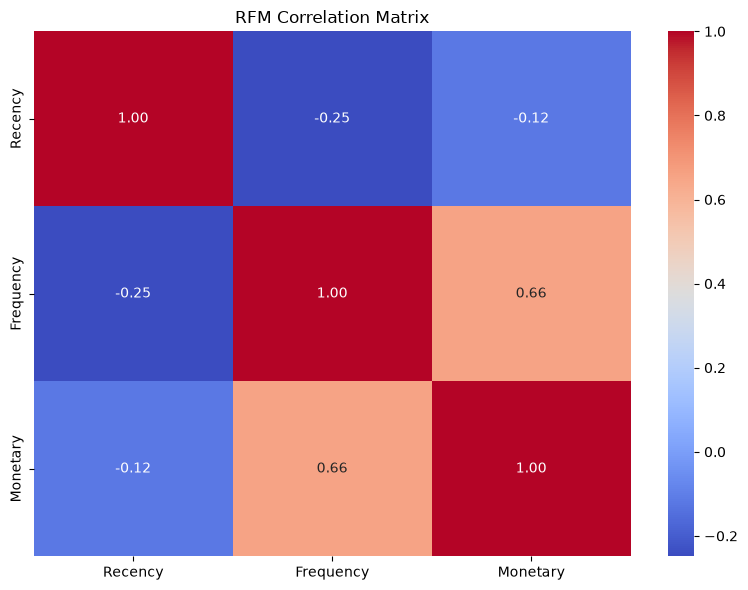

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    rfm_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("RFM Correlation Matrix")
plt.tight_layout()
plt.show()

In [8]:
Q1 = rfm["Monetary"].quantile(0.25)
Q3 = rfm["Monetary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: £{Q1:,.2f}")
print(f"Q3: £{Q3:,.2f}")
print(f"IQR: £{IQR:,.2f}")
print(f"Lower Bound: £{lower_bound:,.2f}")
print(f"Upper Bound: £{upper_bound:,.2f}")

Q1: £307.19
Q3: £1,714.93
IQR: £1,407.75
Lower Bound: £-1,804.43
Upper Bound: £3,826.55


In [9]:
outliers = rfm[
    (rfm["Monetary"] < lower_bound) |
    (rfm["Monetary"] > upper_bound)
]

print("Number of Revenue Outliers:", len(outliers))
print(
    f"Outlier Revenue: "
    f"£{outliers['Monetary'].sum():,.2f}"
)

Number of Revenue Outliers: 423
Outlier Revenue: £5,241,196.18


In [10]:
outlier_revenue_share = (
    outliers["Monetary"].sum()
    / rfm["Monetary"].sum()
) * 100

print(
    f"Outlier Revenue Share: "
    f"{outlier_revenue_share:.2f}%"
)

Outlier Revenue Share: 59.57%
